In [9]:
# load the dataset

import pandas as pd

df = pd.read_csv("creditcardFraud.csv")

# preview data

df.head(5)



,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,False
1,2,541.82,3,Travel,1,0,87,1,64,False
2,3,237.01,17,Grocery,0,0,49,1,61,False
3,4,164.33,4,Grocery,0,1,72,3,34,False
4,5,30.53,15,Food,0,0,79,0,44,False


In [10]:
# understand the data

df.info()
df.describe()
df.isnull().sum()
df['is_fraud'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  bool   
dtypes: bool(1), float64(1), int64(7), object(1)
memory usage: 713.0+ KB


,count
is_fraud,
False,9849
True,151


In [11]:
# amount vs fraud
df.groupby('is_fraud')['amount'].mean()

,amount
is_fraud,
False,175.333015
True,216.182980


In [12]:
# is_ fraud vs velocity_last_24th

df.groupby('is_fraud')['velocity_last_24h'].mean()

,velocity_last_24h
is_fraud,
False,1.990557
True,3.205298


In [13]:
# comparing two columns and count occurances

pd.crosstab(df['foreign_transaction'],df['is_fraud'])

is_fraud,False,True
foreign_transaction,,
0,8953,69
1,896,82


In [14]:
# comparing columns location mistached and is fraud
pd.crosstab(df['location_mismatch'],df['is_fraud'])

is_fraud,False,True
location_mismatch,,
0,9064,79
1,785,72


In [15]:
df. groupby('is_fraud')['device_trust_score'].mean()

,device_trust_score
is_fraud,
False,62.165804
True,37.867550


# From abaove analysis we will create a rules: Amount > 200 , velocity (transactions in last 24h) if transaction in last 2h > 3
# Foreign transaction , if foreign transaction = yes ,  Device trust score , if device trust score > 60 , location mismatch if yes
# This is a strong indicator so based on this we will create a fraud detection rules


In [16]:
# creating Fraud detection rules

# start with 0  risk score

df['fraud_score']= 0

# Rule 1: High Amount

df.loc[df['amount']>200 , 'fraud_score'] +=1

# Rule 2 : High Velocity

df.loc[df['velocity_last_24h'], 'fraud_score'] +=1

# Rule 3 : Foreign Transaction

df.loc[df['foreign_transaction'],'fraud_score'] +=1

# Rule 4 : Device trust score

df.loc[df['device_trust_score'],'fraud_score'] +=0.5

# Rule 5 : Location mismatch

df.loc[df['location_mismatch'],'fraud_score'] +=1



/tmp/ipykernel_1627/4230608901.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.5 0.5 0.5 ... 0.5 1.5 1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['device_trust_score'],'fraud_score'] +=0.5


In [17]:
# checking top 1= transactions with highest fraud score

df.sort_values('fraud_score',ascending=False).head(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,fraud_score
1,2,541.82,3,Travel,1,0,87,1,64,False,4.0
0,1,84.47,22,Electronics,0,0,66,3,40,False,3.0
7,8,362.02,13,Electronics,0,0,68,1,40,False,2.0
9,10,221.63,5,Grocery,0,0,59,1,34,False,2.0
2,3,237.01,17,Grocery,0,0,49,1,61,False,2.0
50,51,628.71,4,Clothing,0,0,30,4,45,False,1.5
51,52,268.60,0,Food,0,0,85,1,34,False,1.5
52,53,504.92,19,Electronics,0,0,56,1,59,False,1.5
53,54,405.39,12,Grocery,0,0,53,0,39,False,1.5
55,56,458.90,5,Travel,0,0,39,1,57,False,1.5


In [18]:
# import libraries
import matplotlib.pyplot as plt
import seaborn as sns

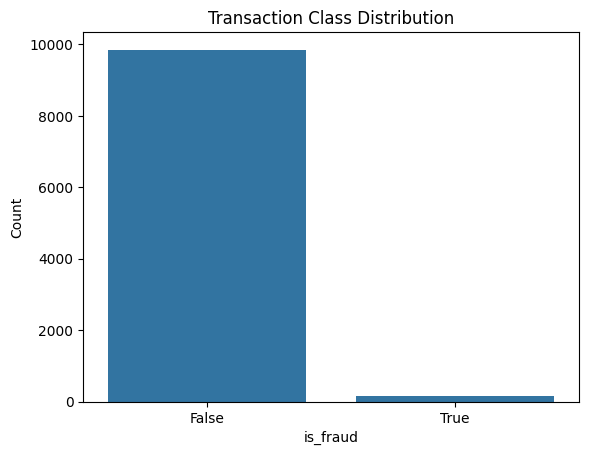

In [19]:
# showing how many transctions are fraud vs non fraud
sns.countplot(x='is_fraud', data=df)
plt.title('Transaction Class Distribution')
plt.xlabel('is_fraud')
plt.ylabel('Count')
plt.show()

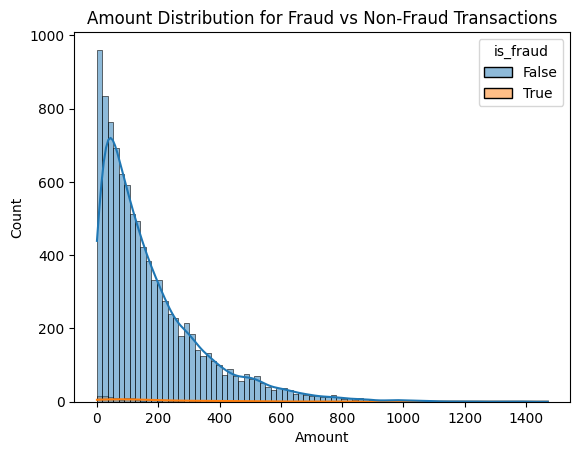

In [20]:
# Amount Dsitribution for fraud Vs Non Fraud

sns.histplot(x='amount', hue='is_fraud', data=df, kde=True)
plt.title('Amount Distribution for Fraud vs Non-Fraud Transactions')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.show()

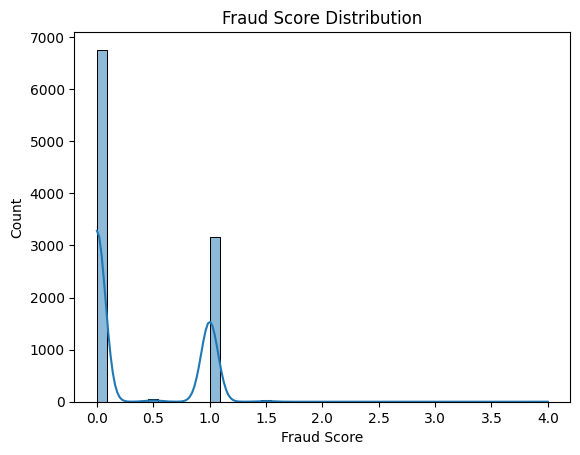

In [21]:
# Fraud score Distribution
sns.histplot(x='fraud_score', data=df, kde=True)
plt.title('Fraud Score Distribution')
plt.xlabel('Fraud Score')
plt.ylabel('Count')
plt.show()

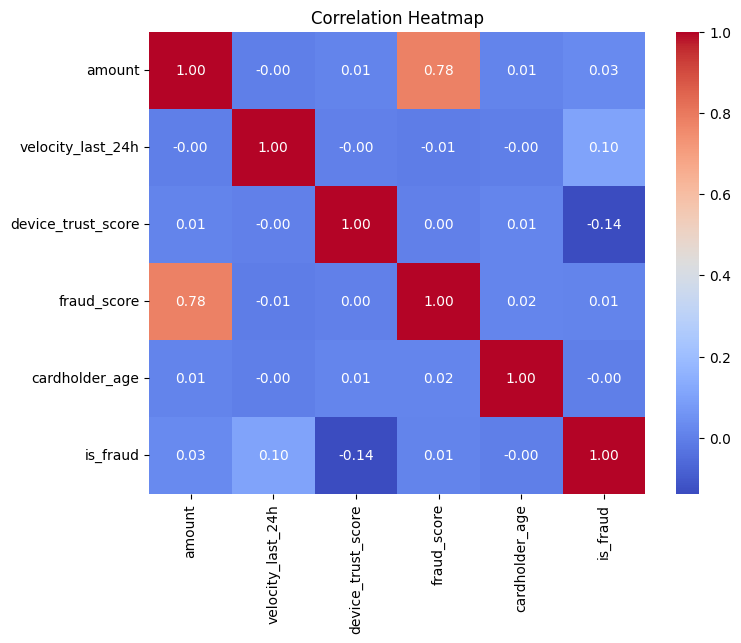

In [22]:
# correlation Heatmap

# select numeric cols
numeric_clos = ['amount','velocity_last_24h','device_trust_score','fraud_score','cardholder_age']

# create correlation matrix
corr_matrix = df[numeric_clos+['is_fraud']].corr()

# create heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

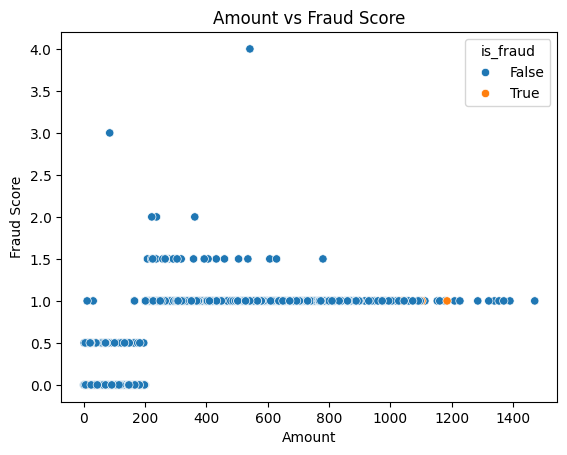

In [23]:
# scatter plot - Amount VS Frad Score

# show how fraud score seperated high risk transaction

sns.scatterplot(x='amount', y='fraud_score', hue='is_fraud', data=df)
plt.title('Amount vs Fraud Score')
plt.xlabel('Amount')
plt.ylabel('Fraud Score')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

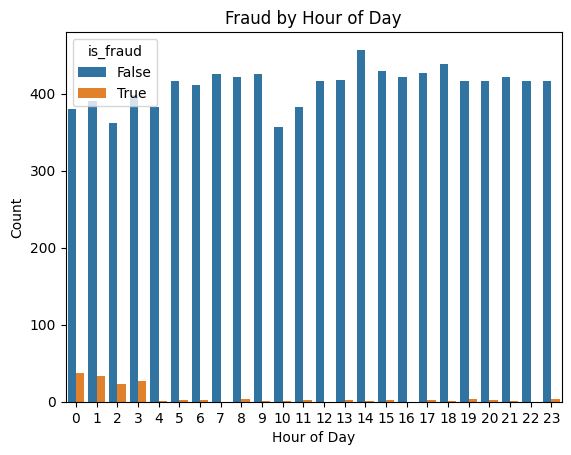

In [24]:
# fraud by hour of day

sns.countplot(x='transaction_hour', hue= 'is_fraud',data = df)
plt.title('Fraud by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show